# Trabajo Práctico Final - Minería de Datos

**Alumno:** Emilio Maidana, Alvaro Ortiz  
**Fecha:**  06/2026
**Materia:** Minería de Datos  


## 1. Introducción


**Título del Proyecto**

Segmentación Estratégica de Clientes en el Sector E-Commerce mediante Técnicas de Reducción de Dimensionalidad y Agrupamiento No Supervisado (PCA + K-Means)

**Resumen**

El presente proyecto aborda el diseño e implementación de un modelo de minería de datos no supervisado orientado a la identificación de perfiles latentes de consumidores en una plataforma de comercio electrónico a gran escala (100,000 registros). Ante esto, se propone un flujo de trabajo metodológico que combina el Análisis de Componentes Principales (PCA) y el algoritmo K-Means para agrupar a los usuarios según su comportamiento transaccional, nivel de fidelización y satisfacción.

**Descripción del dataset**

El proyecto se nutrirá de un dataset estructurado de comportamiento de clientes en canales digitales (E-commerce Customer Behaviour Dataset), el cual consta de 100,000 observaciones (filas) y 11 atributos (columnas) recopilados en formato tabular plano (csv). Aunque el dataset posee un origen simulado algorítmicamente para preservar la confidencialidad, el generador inyectó restricciones de negocio realistas (correlaciones lógicas entre membresías, reseñas insatisfechas y volumen de gasto)

## 2. Importación de librerías


In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

%matplotlib inline
sns.set_theme(style='whitegrid')

## 3. Carga de datos


In [65]:
df = pd.read_csv('ecommerce_customer_data.csv')
print(f'Dimensiones: {df.shape}')
df.head()

Dimensiones: (100000, 11)


,Customer_ID,Gender,Age,City,Membership_Type,Total_Spend,Items_Purchased,Average_Rating,Discount_Applied,Days_Since_Last_Purchase,Satisfaction_Level
0,1,Male,51,San Francisco,Bronze,207.10,4,2.4,True,20,Unsatisfied
1,2,Female,25,Los Angeles,Bronze,186.95,6,3.9,True,62,Neutral
2,3,Female,32,Miami,Bronze,166.56,2,2.5,True,42,Unsatisfied
3,4,Female,34,Los Angeles,Bronze,181.03,3,3.6,True,41,Neutral
4,5,Male,23,San Francisco,Gold,585.91,13,4.6,True,14,Neutral


## 4. Exploración de datos (EDA)


### 4.1 Información general del dataset

In [66]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Customer_ID               100000 non-null  int64  
 1   Gender                    100000 non-null  str    
 2   Age                       100000 non-null  int64  
 3   City                      100000 non-null  str    
 4   Membership_Type           100000 non-null  str    
 5   Total_Spend               100000 non-null  float64
 6   Items_Purchased           100000 non-null  int64  
 7   Average_Rating            100000 non-null  float64
 8   Discount_Applied          100000 non-null  bool   
 9   Days_Since_Last_Purchase  100000 non-null  int64  
 10  Satisfaction_Level        100000 non-null  str    
dtypes: bool(1), float64(2), int64(4), str(4)
memory usage: 7.7 MB


In [67]:
df.describe()

,Customer_ID,Age,Total_Spend,Items_Purchased,Average_Rating,Days_Since_Last_Purchase
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,43.467990,322.241021,6.472330,3.560074,45.091350
std,28867.657797,14.996931,174.249399,5.004329,0.941982,29.921727
min,1.000000,18.000000,63.710000,1.000000,1.000000,1.000000
25%,25000.750000,31.000000,187.130000,3.000000,2.900000,15.000000
50%,50000.500000,43.000000,264.865000,5.000000,3.600000,43.000000
75%,75000.250000,56.000000,374.812500,8.000000,4.300000,71.000000
max,100000.000000,69.000000,750.180000,36.000000,5.000000,99.000000


In [68]:
print('Valores nulos por columna:')
print(df.isnull().sum())

Valores nulos por columna:
Customer_ID                 0
Gender                      0
Age                         0
City                        0
Membership_Type             0
Total_Spend                 0
Items_Purchased             0
Average_Rating              0
Discount_Applied            0
Days_Since_Last_Purchase    0
Satisfaction_Level          0
dtype: int64


### 4.2 Distribución de edades

C:\Users\Alvaro Ortiz\AppData\Local\Temp\ipykernel_9484\1995928015.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Gender', y='Age', ax=axes[1], palette='Set2')


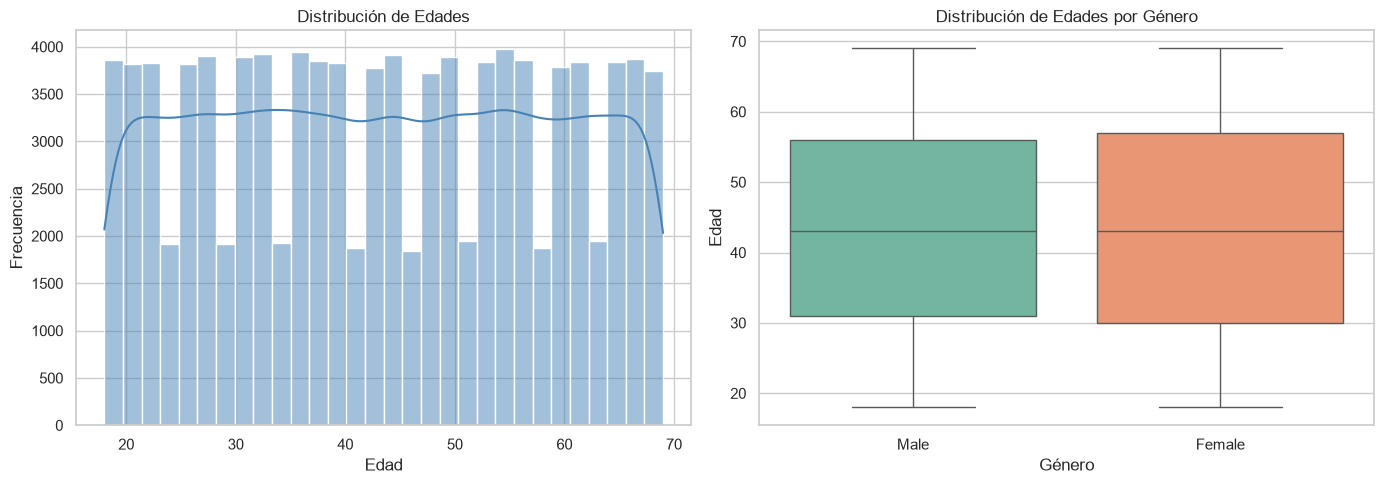

Edad promedio: 43.5 años
Mediana: 43.0 años
Rango: 18 - 69 años


In [69]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['Age'], bins=30, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribución de Edades')
axes[0].set_xlabel('Edad')
axes[0].set_ylabel('Frecuencia')

sns.boxplot(data=df, x='Gender', y='Age', ax=axes[1], palette='Set2')
axes[1].set_title('Distribución de Edades por Género')
axes[1].set_xlabel('Género')
axes[1].set_ylabel('Edad')

plt.tight_layout()
plt.show()

print(f"Edad promedio: {df['Age'].mean():.1f} años")
print(f"Mediana: {df['Age'].median():.1f} años")
print(f"Rango: {df['Age'].min()} - {df['Age'].max()} años")

### 4.3 Distribución de gastos (Total_Spend)

C:\Users\Alvaro Ortiz\AppData\Local\Temp\ipykernel_9484\979059107.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Membership_Type', y='Total_Spend', ax=axes[1], palette='Set3')


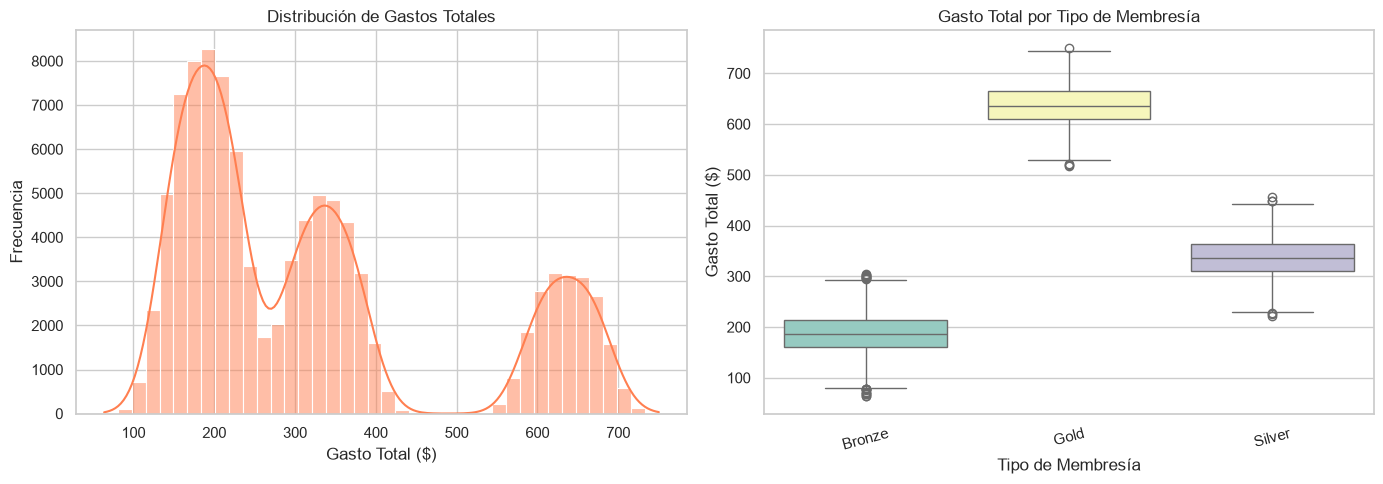

Gasto promedio: $322.24
Mediana: $264.87
Rango: $63.71 - $750.18


In [70]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['Total_Spend'], bins=40, kde=True, ax=axes[0], color='coral')
axes[0].set_title('Distribución de Gastos Totales')
axes[0].set_xlabel('Gasto Total ($)')
axes[0].set_ylabel('Frecuencia')

sns.boxplot(data=df, x='Membership_Type', y='Total_Spend', ax=axes[1], palette='Set3')
axes[1].set_title('Gasto Total por Tipo de Membresía')
axes[1].set_xlabel('Tipo de Membresía')
axes[1].set_ylabel('Gasto Total ($)')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

print(f"Gasto promedio: ${df['Total_Spend'].mean():.2f}")
print(f"Mediana: ${df['Total_Spend'].median():.2f}")
print(f"Rango: ${df['Total_Spend'].min():.2f} - ${df['Total_Spend'].max():.2f}")

### 4.4 Relación entre edad y gasto

C:\Users\Alvaro Ortiz\AppData\Local\Temp\ipykernel_9484\1780350311.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=gasto_por_edad, x='Age_Group', y='Total_Spend', ax=axes[1], palette='Blues_d')


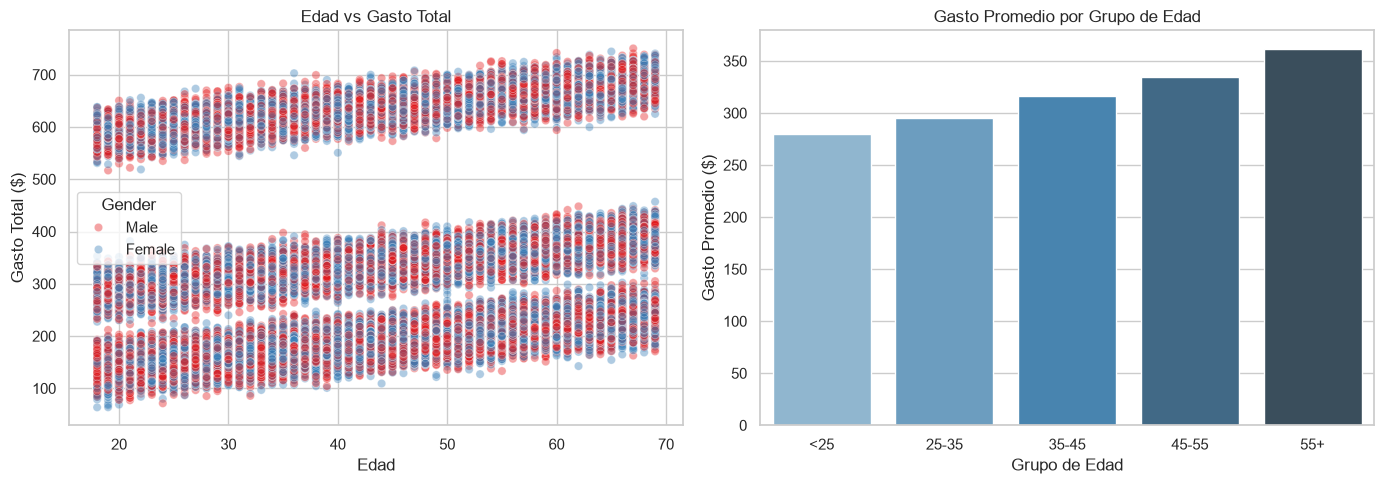

In [71]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=df, x='Age', y='Total_Spend', hue='Gender', alpha=0.4, ax=axes[0], palette='Set1')
axes[0].set_title('Edad vs Gasto Total')
axes[0].set_xlabel('Edad')
axes[0].set_ylabel('Gasto Total ($)')

df['Age_Group'] = pd.cut(df['Age'], bins=[0, 25, 35, 45, 55, 100],
                          labels=['<25', '25-35', '35-45', '45-55', '55+'])
gasto_por_edad = df.groupby('Age_Group', observed=True)['Total_Spend'].mean().reset_index()
sns.barplot(data=gasto_por_edad, x='Age_Group', y='Total_Spend', ax=axes[1], palette='Blues_d')
axes[1].set_title('Gasto Promedio por Grupo de Edad')
axes[1].set_xlabel('Grupo de Edad')
axes[1].set_ylabel('Gasto Promedio ($)')

plt.tight_layout()
plt.show()

### 4.5 Variables categóricas

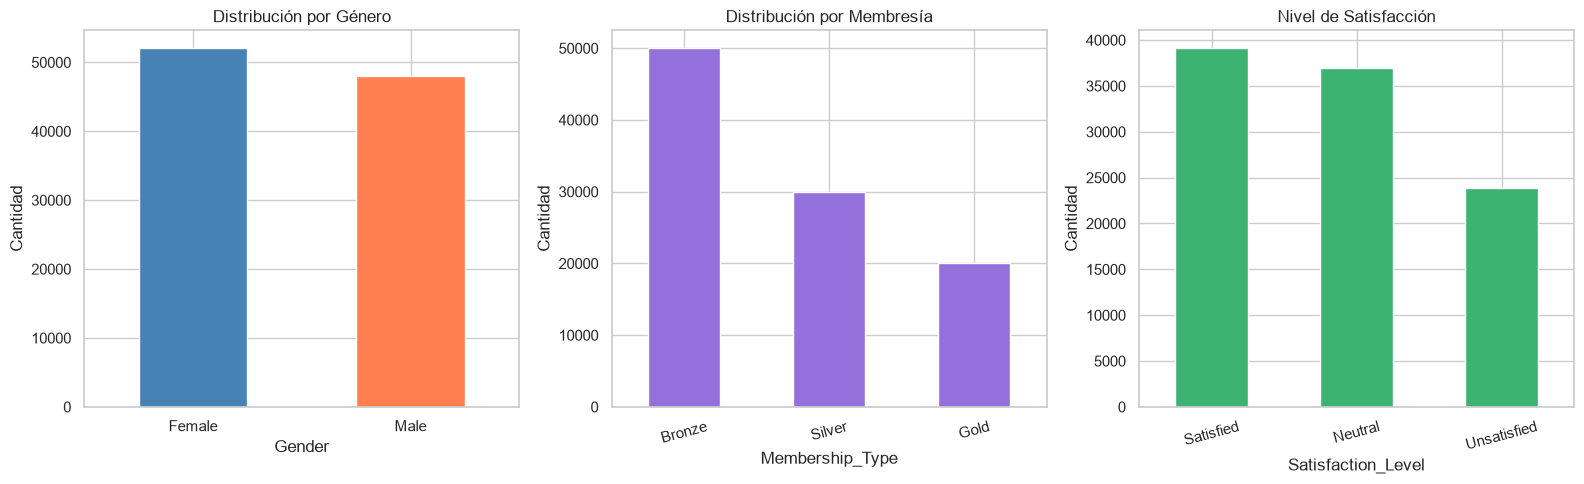

In [72]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

df['Gender'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'coral'], rot=0)
axes[0].set_title('Distribución por Género')
axes[0].set_ylabel('Cantidad')

df['Membership_Type'].value_counts().plot(kind='bar', ax=axes[1], color='mediumpurple', rot=15)
axes[1].set_title('Distribución por Membresía')
axes[1].set_ylabel('Cantidad')

df['Satisfaction_Level'].value_counts().plot(kind='bar', ax=axes[2], color='mediumseagreen', rot=15)
axes[2].set_title('Nivel de Satisfacción')
axes[2].set_ylabel('Cantidad')

plt.tight_layout()
plt.show()

### 4.6 Matriz de correlación

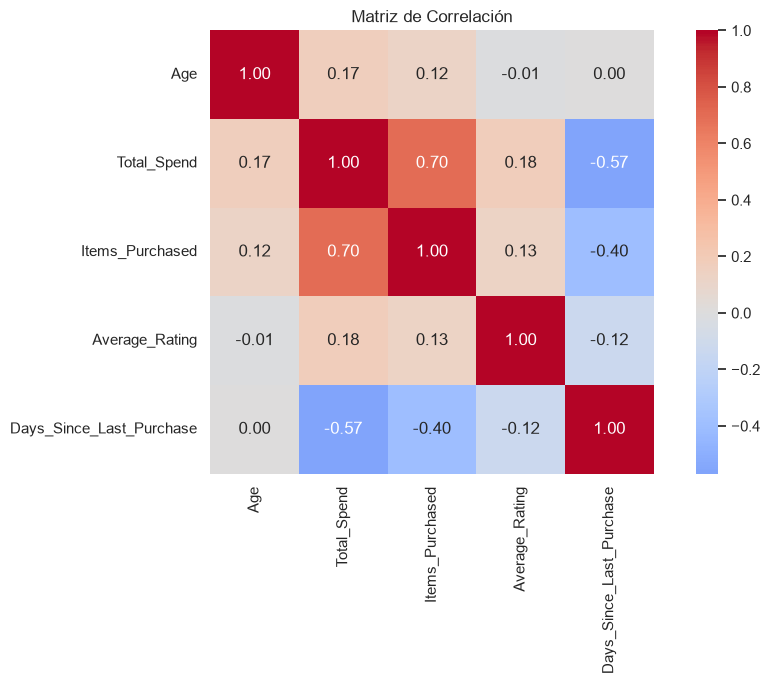

In [73]:
numeric_cols = df.select_dtypes(include=np.number).drop(columns=['Customer_ID'])
corr_matrix = numeric_cols.corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Matriz de Correlación')
plt.tight_layout()
plt.show()

## 5. Preprocesamiento


### 5.1 Separar variable de validación

`Satisfaction_Level` se aparta del conjunto de features y se usará **después del clustering** para validar si los segmentos encontrados tienen coherencia con el nivel de satisfacción real de los clientes.

In [74]:
satisfaction = df['Satisfaction_Level'].copy()

df_proc = df.drop(columns=['Customer_ID', 'Age_Group', 'Satisfaction_Level']).copy()
print(f'Features para modelar: {df_proc.columns.tolist()}')

Features para modelar: ['Gender', 'Age', 'City', 'Membership_Type', 'Total_Spend', 'Items_Purchased', 'Average_Rating', 'Discount_Applied', 'Days_Since_Last_Purchase']


### 5.2 Encoding con OneHotEncoder

Las variables `Gender`, `City` y `Membership_Type` son **nominales** (no tienen orden inherente). Usar `LabelEncoder` introduciría una relación ordinal artificial (ej: City A=0 < City B=1) que distorsionaría tanto PCA como K-Means. `OneHotEncoder` crea una columna binaria por categoría, evitando ese problema.

In [75]:
nominal_cols = ['Gender', 'City', 'Membership_Type']
numeric_cols = ['Age', 'Total_Spend', 'Items_Purchased', 'Average_Rating', 'Days_Since_Last_Purchase']

ohe = OneHotEncoder(sparse_output=False, drop='first')
encoded = ohe.fit_transform(df_proc[nominal_cols])
encoded_df = pd.DataFrame(encoded, columns=ohe.get_feature_names_out(nominal_cols))

df_proc = df_proc.drop(columns=nominal_cols).reset_index(drop=True)
df_proc['Discount_Applied'] = df_proc['Discount_Applied'].astype(int)
df_proc = pd.concat([df_proc, encoded_df], axis=1)

print(f'Dimensiones tras encoding: {df_proc.shape}')
df_proc.head()

Dimensiones tras encoding: (100000, 14)


,Age,Total_Spend,Items_Purchased,Average_Rating,Discount_Applied,Days_Since_Last_Purchase,Gender_Male,City_Houston,City_Los Angeles,City_Miami,City_New York,City_San Francisco,Membership_Type_Gold,Membership_Type_Silver
0,51,207.10,4,2.4,1,20,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,25,186.95,6,3.9,1,62,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,32,166.56,2,2.5,1,42,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,34,181.03,3,3.6,1,41,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,23,585.91,13,4.6,1,14,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0


### 5.3 Escalado con RobustScaler

> **¿Por qué RobustScaler?**  
> Variables como `Total_Spend` tienen outliers en datos de e-commerce. `RobustScaler` usa la **mediana** y el **IQR** en lugar de media/desviación estándar, haciéndolo más resistente a esos valores extremos. Solo se escalan las columnas numéricas continuas; las columnas binarias del OHE ya están en escala [0, 1].

In [76]:
scaler = RobustScaler()
df_proc[numeric_cols] = scaler.fit_transform(df_proc[numeric_cols])

print('Estadísticas tras el escalado:')
df_proc[numeric_cols].describe().round(3)

Estadísticas tras el escalado:


,Age,Total_Spend,Items_Purchased,Average_Rating,Days_Since_Last_Purchase
count,100000.000,100000.000,100000.000,100000.000,100000.000
mean,0.019,0.306,0.294,-0.029,0.037
std,0.600,0.928,1.001,0.673,0.534
min,-1.000,-1.072,-0.800,-1.857,-0.750
25%,-0.480,-0.414,-0.400,-0.500,-0.500
50%,0.000,0.000,0.000,0.000,0.000
75%,0.520,0.586,0.600,0.500,0.500
max,1.040,2.586,6.200,1.000,1.000


## 6. Modelado


### 6.1 PCA — Reducción de dimensionalidad

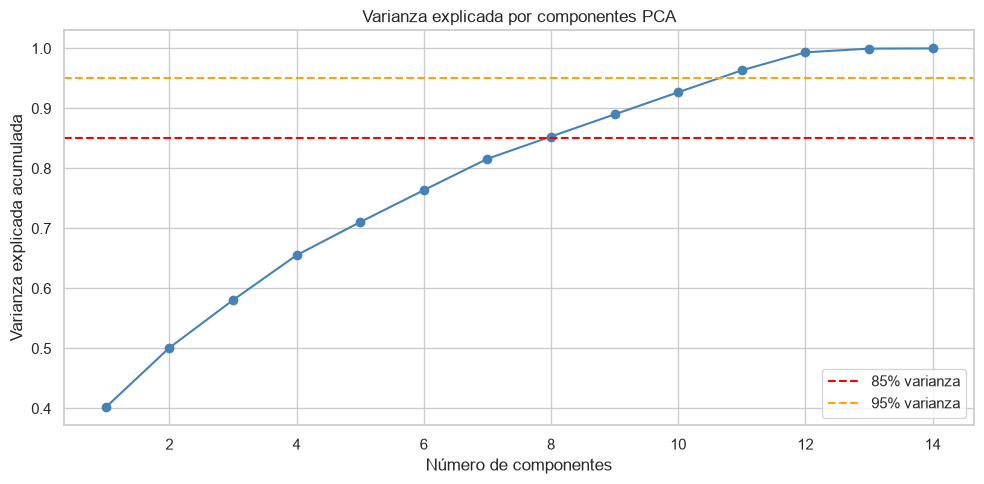

Componentes para 85% de varianza: 8
Componentes para 95% de varianza: 11


In [77]:
pca_full = PCA()
pca_full.fit(df_proc)

varianza_acumulada = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada, marker='o', color='steelblue')
plt.axhline(y=0.85, color='red', linestyle='--', label='85% varianza')
plt.axhline(y=0.95, color='orange', linestyle='--', label='95% varianza')
plt.xlabel('Número de componentes')
plt.ylabel('Varianza explicada acumulada')
plt.title('Varianza explicada por componentes PCA')
plt.legend()
plt.tight_layout()
plt.show()

n_85 = np.argmax(varianza_acumulada >= 0.85) + 1
n_95 = np.argmax(varianza_acumulada >= 0.95) + 1
print(f'Componentes para 85% de varianza: {n_85}')
print(f'Componentes para 95% de varianza: {n_95}')

In [78]:
N_COMPONENTS = n_85

pca = PCA(n_components=N_COMPONENTS, random_state=42)
X_pca = pca.fit_transform(df_proc)

print(f'Dimensiones originales: {df_proc.shape[1]}')
print(f'Dimensiones tras PCA:   {X_pca.shape[1]}')
print(f'Varianza explicada:     {pca.explained_variance_ratio_.sum():.2%}')

Dimensiones originales: 14
Dimensiones tras PCA:   8
Varianza explicada:     85.31%


### 6.2 Selección de k — Elbow Method y Silhouette Score

In [79]:
k_range = range(2, 11)
inercias = []
silhouettes = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_pca)
    inercias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_pca, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, inercias, marker='o', color='steelblue')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Número de clusters (k)')
axes[0].set_ylabel('Inercia')

axes[1].plot(k_range, silhouettes, marker='o', color='coral')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Número de clusters (k)')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

best_k = list(k_range)[np.argmax(silhouettes)]
print(f'Mejor k según Silhouette Score: {best_k} (score={max(silhouettes):.4f})')

KeyboardInterrupt: 

### 6.3 K-Means

In [ ]:
K = 4

kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_pca)

print(f'Clusters generados: {K}')
print(df['Cluster'].value_counts().sort_index())

Clusters generados: 4
Cluster
0    30396
1    49338
2     5418
3    14848
Name: count, dtype: int64


### 6.4 Visualización de clusters (PC1 vs PC2)

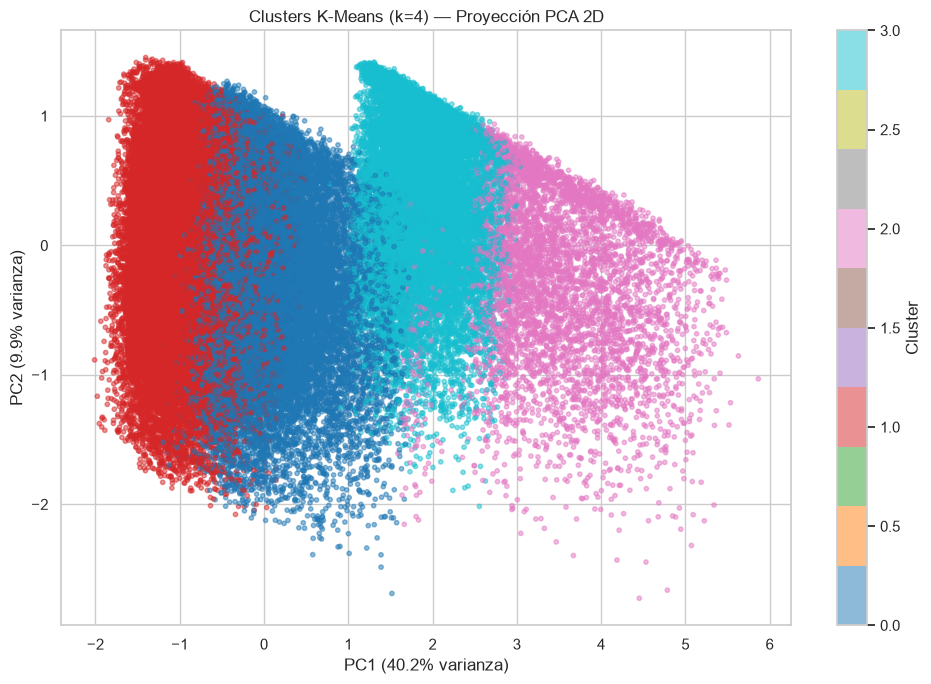

In [ ]:
pca_2d = PCA(n_components=2, random_state=42)
X_2d = pca_2d.fit_transform(df_proc)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=df['Cluster'], cmap='tab10', alpha=0.5, s=10)
plt.colorbar(scatter, label='Cluster')
plt.title(f'Clusters K-Means (k={K}) — Proyección PCA 2D')
plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} varianza)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} varianza)')
plt.tight_layout()
plt.show()

## 7. Evaluación de resultados


### 7.1 Perfil de cada cluster

In [ ]:
perfil = df.groupby('Cluster')[['Age', 'Total_Spend', 'Items_Purchased',
                                 'Average_Rating', 'Days_Since_Last_Purchase']].mean().round(2)
perfil['n'] = df['Cluster'].value_counts().sort_index()
perfil

,Age,Total_Spend,Items_Purchased,Average_Rating,Days_Since_Last_Purchase,n
Cluster,,,,,,
0,43.84,334.85,6.77,3.48,54.77,30396
1,43.19,186.23,3.67,3.46,54.42,49338
2,45.21,631.93,21.71,3.93,8.74,5418
3,42.99,635.37,9.61,3.92,7.54,14848


### 7.2 Validación con Satisfaction_Level

Distribución de Satisfaction_Level por cluster (proporciones):
Satisfaction_Level  Neutral  Satisfied  Unsatisfied
Cluster                                            
0                     0.378      0.366        0.256
1                     0.380      0.362        0.259
2                     0.342      0.493        0.165
3                     0.332      0.503        0.165


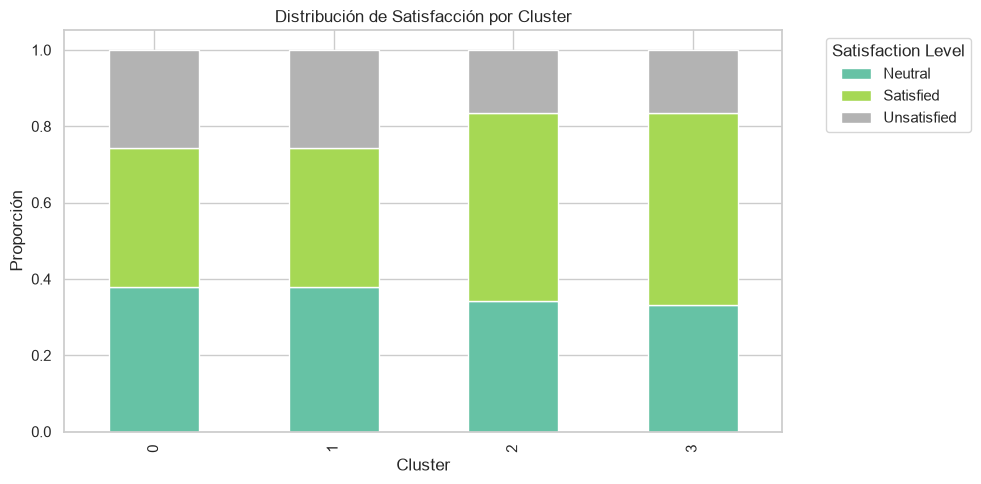

In [ ]:
df['Satisfaction_Level'] = satisfaction.values

tabla = pd.crosstab(df['Cluster'], df['Satisfaction_Level'], normalize='index').round(3)
print('Distribución de Satisfaction_Level por cluster (proporciones):')
print(tabla)

tabla.plot(kind='bar', stacked=True, figsize=(10, 5), colormap='Set2')
plt.title('Distribución de Satisfacción por Cluster')
plt.xlabel('Cluster')
plt.ylabel('Proporción')
plt.legend(title='Satisfaction Level', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

## 8. Conclusiones

### Síntesis del análisis

Se aplicó un pipeline de **PCA + K-Means (k=4)** sobre un dataset de 100.000 clientes de e-commerce con 11 variables originales. Tras el preprocesamiento (OneHotEncoder para variables nominales y RobustScaler para variables numéricas), PCA redujo la dimensionalidad preservando el 85% de la varianza explicada. El componente principal PC1 captura el **40.2% de la varianza total** y representa principalmente el eje de actividad y gasto, que resultó ser el factor dominante de segmentación. La variable demográfica **edad no diferencia los segmentos** (promedio de 43-45 años en todos los clusters), lo que indica que el comportamiento de compra es más relevante que el perfil etario.

---

### Segmentos identificados

| Cluster | Nombre | Total_Spend | Items | Días inactivo | n | % base |
|---|---|---|---|---|---|---|
| 0 | Compradores ocasionales | $334.85 | 6.77 | 54.77 | 30.396 | 30% |
| 1 | Clientes dormidos | $186.23 | 3.67 | 54.42 | 49.338 | 49% |
| 2 | Compradores mayoristas | $631.93 | 21.71 | 8.74 | 5.418 | 5% |
| 3 | Clientes premium | $635.37 | 9.61 | 7.54 | 14.848 | 15% |

---

### Hallazgos clave

**1. La inactividad se correlaciona con insatisfacción**  
Los clusters 0 y 1 (inactivos ~55 días) presentan los índices de insatisfacción más altos (~25-26%), mientras que los clusters activos 2 y 3 (inactivos menos de 9 días) tienen solo un 16.5% de insatisfacción y superan el 49% de clientes satisfechos. Esto sugiere que la **insatisfacción es una causa del abandono**, no una consecuencia, lo que refuerza la importancia de la experiencia post-compra.

**2. El 49% de la base está en riesgo**  
El cluster 1 representa casi la mitad de los clientes con el menor gasto, menor frecuencia y mayor insatisfacción. Sin intervención, este segmento representa una pérdida de ingresos potenciales significativa.

**3. El 5% de clientes mayoristas genera valor desproporcionado**  
El cluster 2 compra en promedio 21 items por transacción con alta frecuencia. Son probablemente revendedores o compradores B2B que merecen un tratamiento diferenciado.

---

### Reglas de negocio

- **Cluster 1 — Clientes dormidos**: activar campaña de reactivación automática a los 30 días de inactividad con descuento de primera recompra. Si no responden en 90 días, reclasificar como churn.
- **Cluster 0 — Compradores ocasionales**: estrategia de cross-selling basada en historial de compra e incentivos para subir de membresía.
- **Cluster 3 — Clientes premium**: programa de fidelización exclusivo con acceso anticipado a productos. Evitar descuentos masivos para no erosionar margen.
- **Cluster 2 — Compradores mayoristas**: evaluar plan de precios mayorista diferenciado. Representan solo el 5% de clientes pero tienen el mayor volumen de items por transacción.